# 1

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import *
from data_fit import *
from data_plot import *
import scipy
from scipy.optimize import minimize
from matplotlib.ticker import ScalarFormatter
from lmfit import models
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy import interpolate
from scipy import integrate
import plotly.graph_objects as go
import plotly.express as px
pi = np.pi

In [3]:
def Gauss_C(x, A, m, s, C):
    return A*np.exp(-np.power((x-m)/s, 2)) + C

def Lorenz(x, A, m, s):
    return A*(1/(1+s**(-2)*(x-m)**2))

def Voigt(x, sigma, gamma):
    return voigt_profile(x, sigma, gamma)

def Model_fit(x, A1, x1, sigma1, gamma1, A2, x2, sigma2, gamma2, A3, x3, sigma3, gamma3, A4, x4, sigma4):
    return A1*Voigt(x-x1, sigma1, gamma1)+A2*Voigt(x-x2, sigma2, gamma2)+A3*Voigt(x-x3, sigma3, gamma3)+A4*gaussian(x, x4, sigma4)

def Model_fit_v2(x, A1, x1, sigma1, gamma1, A2, x2, sigma2, A3, x3, sigma3, A4, x4, sigma4, A5, x5, sigma5):
    return A1*Voigt(x-x1, sigma1, gamma1) + A2*gaussian(x-x2, sigma2) + A3*gaussian(x-x3, sigma3) + A4*gaussian(x-x4, sigma4)+A5*gaussian(x, x5, sigma5)


def lin_interp(x, y, i, half):
    return x[i] + (x[i+1] - x[i]) * ((half - y[i]) / (y[i+1] - y[i]))

def half_max_x(x, y):
    half = max(y)/2.0
    signs = np.sign(np.add(y, -half))
    zero_crossings = (signs[0:-2] != signs[1:-1])
    zero_crossings_i = np.where(zero_crossings)[0]
    return [lin_interp(x, y, zero_crossings_i[0], half),
            lin_interp(x, y, zero_crossings_i[1], half)]

def Gaussian(R, sigma, Ravg):
    return 1/(sigma * np.sqrt(2*np.pi)) * np.exp((-1/(2*sigma**2)) * (R-Ravg)**2)

def Gauss(x, A, x_peak, s, k, b):
    return A*np.exp(-np.power((x-x_peak)/s, 2)) + k*x + b

def Polydisperse_spheres(x, scale, Ravg, p, ro, bkg):
    global counter 
    global sigma
    sigma = p*Ravg
    lowest_R = max((Ravg - 3*sigma), 0.00001)
    highest_R = Ravg + 3*sigma
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        #f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2)
        Iq.append(((4*np.pi / 3)**2) * (ro**2) * integrate.quad(lambda R: (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2), lowest_R, highest_R)[0] + bkg)
    #f = np.array(f)
    #counter +=1
    return Iq


def Model_Lp(x, scale, Ravg, p, ro, bkg, A, m, sigma, gamma):
    return Polydisperse_spheres(x, scale, Ravg, p, ro, bkg) + A*Voigt(x-m, sigma, gamma)

def Appr_func(x, C, x_peak, A, gamma, sigma):
    return C + A*Gauss(x-x_peak, sigma, gamma)

def Appr_func_v2(x, k, b, x_peak, A, sigma):
    return k*x+b + A*Gauss(x, x_peak, sigma)

def FormFact(x, scale, Ravg, p, ro, bkg, A, s, start):
    return Polydisperse_spheres(x, scale, Ravg, p, ro, bkg) + A*lognorm.pdf(x, s, start)

def sigmoid(x, A, alpha, m):
  return A / (1 + np.exp(-alpha*(-x+m)))

# 2

In [ ]:
path = r'D:\BM26\PEG_PNIPAM_292_12_Cryst_at_15C'

Exp = BM26_experiment(path)
T = Exp.get_T_profile()
fig = px.scatter(T, color_discrete_sequence=['blue'])
fig.show()

In [ ]:
lst_A = []
lst_b = []
for n in range(30, 40, 2):
    SAXS_plot(6, 6)
    plt.xlim([0.8, 4])
    plt.ylim([0.9e-2,1.8e-2])
    q1, I1 = Exp.get_1d_SAXS(n)
    q2, I2 = Exp.get_1d_SAXS(n+1)
    I = I1/2+I2/2
    plt.scatter(q, I, s=3, alpha=0.4)
    x, y = q[-675:-202], I[-675:-202]
    plt.plot(q[-202], I[-202], 'x', color='black', markersize=12)
    plt.plot(q[-675], I[-675], 'x', color='black', markersize=12)
    #p0 = [1e-2, 1.7, 1, 1.2e-2]
    p0 = [1e-2, 1.7, 1, 0, 1.2e-2]
    popt, pcov = curve_fit(Gauss, x, y, p0 = p0)
    plt.plot(x, Gauss(x, *popt))
    lst_A.append(popt[0])
    lst_b.append(popt[-1])

fig = px.scatter(lst_A, color_discrete_sequence=['blue'])
fig.update_yaxes(exponentformat="none",showexponent="all")
fig.show()
fig = px.scatter(lst_b, color_discrete_sequence=['blue'])
fig.show()

In [ ]:
path = r'D:\BM26\PEG_PNIPAM_292_6_Cryst_at_10C'

Exp = BM26_experiment(path)
T = Exp.get_T_profile()
fig = px.scatter(T, color_discrete_sequence=['blue'])
fig.show()

In [ ]:
path = r'D:\BM26\PEG_PNIPAM_576_6_Cryst_at_10C'

Exp = BM26_experiment(path)
T = Exp.get_T_profile()
fig = px.scatter(T, color_discrete_sequence=['blue'])
fig.show()

In [9]:
def Avrami(x, A, k, n):
    return A * (1 - np.exp(-k * x ** n))

def Avrami_shifted(x, A, k, n, x0):
    res = Avrami(abs(x-x0), A, k, n)
    res[x < x0] *= 0
   
    return res

def Avraami_2(t, A, K1, n1, K2, n2):
    N = 100
    theta_arr = np.linspace(0, t, N)
    res = 0
    for theta in theta_arr:
        res += (1 - np.exp(-K2 * (t - theta) ** n2)) * theta ** (n1 - 1) * np.exp(-K1 * (theta ** n1)) * t / N
    return A * K1 * n1 * res
   
def Avraami_2_linspace(t, A, K1, n1, K2, n2):
    res = np.zeros(len(t))
 
    for i in range(len(t)):
        res[i] = Avraami_2(t[i], A, K1, n1, K2, n2)
    return res

def ResultModel(t, A1, A2, K2, n2):
    K1 = 1.7692541668264953e-07
    n1 = 2.533933760029574
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

font = {'family': 'Arial',
        'color': 'black',
        'weight': 'normal',
        'size': 20}
color_BB = '#ff0f7b'
color_cr = '#072ac8'
lst_A1 = []
lst_K1 = []
lst_n1 = []
lst_A2 = []
lst_K2 = []
lst_n2 = []

# MAIN

['292_12_Cryst_at_10C.txt' '292_12_Cryst_at_15C.txt'
 '292_12_Cryst_at_17_5C.txt' '292_24_Cryst_at_20C.txt'
 '292_6_Cryst_at_10C.txt' '292_6_Cryst_at_5C.txt'
 '576_12_Cryst_at_10C.txt' '576_12_Cryst_at_15C.txt'
 '576_12_Cryst_at_5C.txt' '576_24_Cryst_at_10C.txt'
 '576_24_Cryst_at_15C_second_sample.txt' '576_24_Cryst_at_20C.txt'
 '576_24_Cryst_at_5C.txt' '576_6_Cryst_at_0C.txt' '576_6_Cryst_at_10C.txt'
 '576_6_Cryst_at_15C.txt' '576_6_Cryst_at_5C.txt'
 '888_24_Cryst_at_15C.txt' '292_24_Cryst_at_10C.txt']
[1.00494542e+00 1.86663343e-07 2.52434554e+00]


C:\Users\LabPC\AppData\Local\Temp\ipykernel_11296\4245596131.py:15: RuntimeWarning:

divide by zero encountered in scalar power



0.26808744307593774 0.3644919911670766 0.0012795649048243215 1.2130752693376654


[]

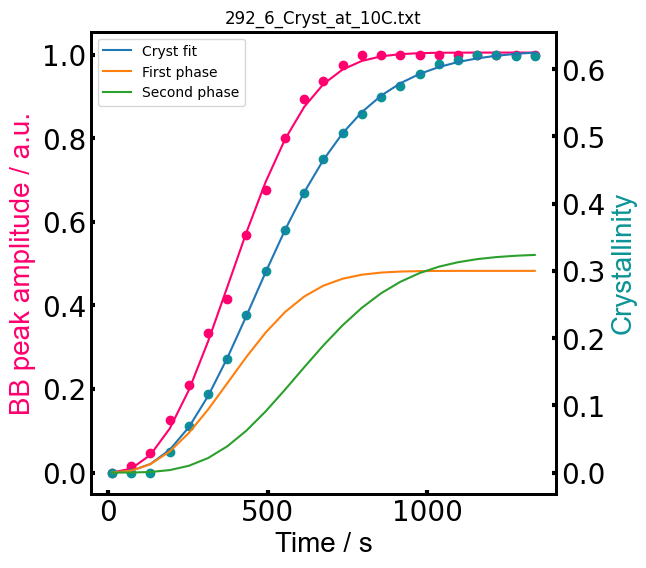

In [10]:
path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
print(file_list)
df = pd.read_csv(path + '/' + file_list[4], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])
fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)


x = df['T'][1:24]
q = df['q'][1:24]
q/=q[1]
cr = df['cr'][1:24]
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0)
ax.scatter(x, 1 - q, color='#ff006e')
ax.plot(x, Avrami(x, *popt), color='#ff006e', label=f'BB fit')
print(popt)
lst_K1.append(popt[1])
lst_n1.append(popt[2])
p0 = [0.3, 0.3, 1e-3, 1.5]
popt, pcov = curve_fit(ResultModel, np.array(x), cr, p0=p0)
print(*popt)
A1, A2, K2, n2 = popt
lst_A1.append(A1)
lst_A2.append(A2)
lst_K2.append(K2)
lst_n2.append(n2)
ax_2.plot(x, ResultModel(np.array(x), *popt), label=f'Cryst fit')
ax_2.plot(x, Avrami(x, 0.3, 1.7692541e-07, 2.53393), label=f'First phase')
ax_2.plot(x, Avraami_2_linspace(np.array(x), 0.328857, 1.7692541e-07, 2.53393, 0.0002571072, 1.4873993), label=f'Second phase')
plt.legend()
plt.title(file_list[4])
ax_2.scatter(x, cr, color='#0a9396')
plt.plot()

[1.00309045e+00 9.79189024e-08 2.99999998e+00]
0.264685 0.44997 0.006563 1.101878
[np.float64(0.0012795649048243215), np.float64(0.00656315852376053)]


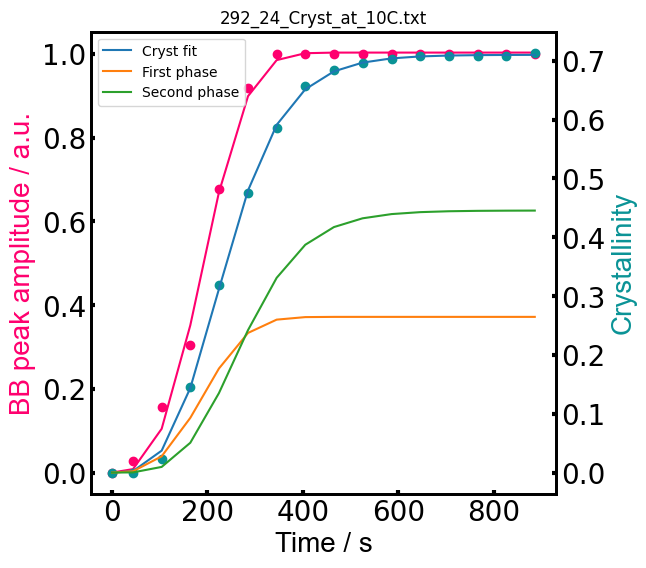

In [11]:
def ResultModel_2(t, A1, A2, K2, n2):
    K1 = 9.81576143e-08
    n1 = 3
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
#print(file_list)
df = pd.read_csv(path + '/' + file_list[-1], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)


x = df['T'][:-27]
q = df['q'][:-27]
cr = df['cr'][:-27]
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.scatter(x, 1 - q, color='#ff006e')
ax.plot(x, Avrami(x, *popt), color='#ff006e', label=f'BB fit')
print(popt)
lst_K1.append(popt[1])
lst_n1.append(popt[2])

p0 = [0.27, 0.45, 0.000308491, 1.681110]
popt, pcov = curve_fit(ResultModel_2, np.array(x), cr, p0=p0)
print(*list(map(round, popt, [6]*len(popt))))
A1, A2, K2, n2 = popt
lst_A1.append(A1)
lst_A2.append(A2)
lst_K2.append(K2)
lst_n2.append(n2)
ax_2.plot(x, ResultModel_2(np.array(x), *popt), label=f'Cryst fit')
ax_2.plot(x, Avrami(x, A1, 9.81576143e-08, 3), label=f'First phase')
ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 9.81576143e-08, 3, K2, n2), label=f'Second phase')
plt.legend()
plt.title(file_list[-1])
ax_2.scatter(x, cr, color='#0a9396')
plt.plot()
print(lst_K2)

C:\Users\LabPC\AppData\Local\Temp\ipykernel_11296\4245596131.py:2: RuntimeWarning:

divide by zero encountered in power



[1.00006820e+00 1.64570265e-07 2.89589780e+00]
0.289507 0.4 0.014966 0.878515


[]

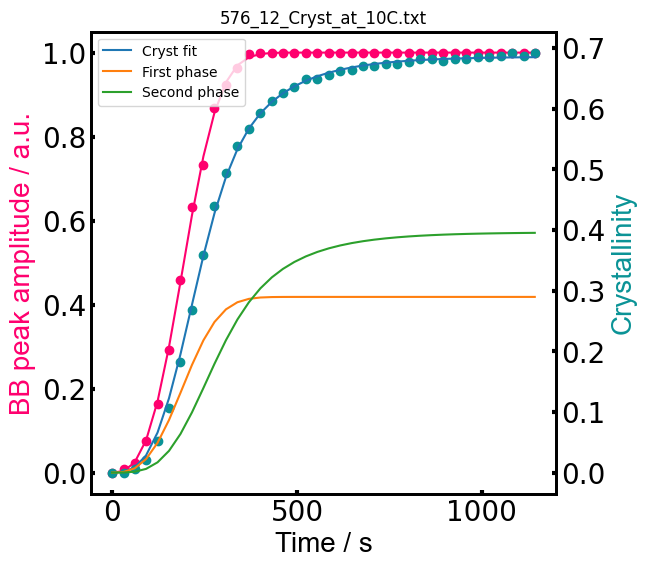

In [12]:
def ResultModel_3(t, A1, A2, K2, n2):
    K1 =1.64525199e-07
    n1 = 2.8959
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
#print(file_list)
df = pd.read_csv(path + '/' + file_list[6], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)


x = df['T'][:-25:2]
q = df['q'][:-25:2]
cr = df['cr'][:-25:2]
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0)
ax.scatter(x, 1 -q, color='#ff006e')
ax.plot(x, Avrami(x, *popt), color='#ff006e', label=f'BB fit')
lst_K1.append(popt[1])
lst_n1.append(popt[2])
print(popt)
p0 = [0.41, 0.27, 0.000708491, 1.481110]
popt, pcov = curve_fit(ResultModel_3, np.array(x), cr, p0=p0, bounds=([0.15,0,0,0.5], [1, 0.4, 1e-1, 4]))
print(*list(map(round, popt, [6]*len(popt))))
A1, A2, K2, n2 = popt
lst_A1.append(A1)
lst_A2.append(A2)
lst_K2.append(K2)
lst_n2.append(n2)
ax_2.plot(x, ResultModel_3(np.array(x), *popt), label=f'Cryst fit')
ax_2.plot(x, Avrami(x, A1, 1.64525199e-07, 2.895953), label=f'First phase')
ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 1.64525199e-07, 2.895953, K2, n2), label=f'Second phase')
plt.legend()
plt.title(file_list[6])
ax_2.scatter(x, cr, color='#0a9396')
plt.plot()

[1.00655331e+00 3.53569336e-08 2.99999998e+00]


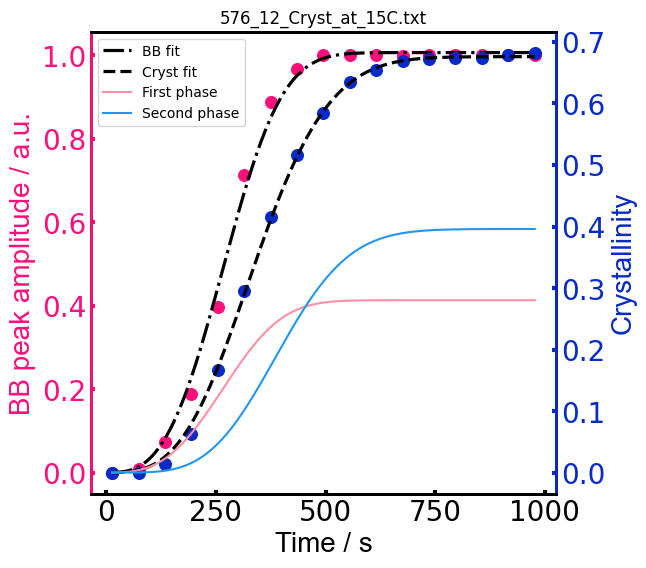

In [13]:
def ResultModel_4(t, A1, A2, K2, n2):
    K1 = 3.56064521e-08
    n1 = 2.9999
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)


path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
#print(file_list)
df = pd.read_csv(path + '/' + file_list[7], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color=color_BB, fontdict=font)
ax_2.set_ylabel('Crystallinity', color=color_cr, fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)
ax_2.spines['left'].set_color(color_BB)
ax.tick_params(axis='y', colors=color_BB)
ax_2.spines['right'].set_color(color_cr)
ax_2.tick_params(axis='y', colors=color_cr)

x = df['T'][1:-23]
x_points=np.linspace(np.min(x), np.max(x), 1000)
q = df['q'][1:-23]
cr = df['cr'][1:-23]

ax.scatter(x, 1-q, color=color_BB, s=70)
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0,0,1], [1.1,1e-1, 3]))
line_bb = ax.plot(x_points, Avrami(x_points, *popt), linestyle='dashdot', linewidth=2.3,color='black', label=f'BB fit')
lst_K1.append(popt[1])
lst_n1.append(popt[2])
print(popt)
# , bounds=([0.15,0,0,0.5], [1, 0.4, 1e-1, 4])
p0 = [0.280153, 0.4, 0.000136, 1.794014]
# popt, pcov = curve_fit(ResultModel_4, np.array(x), cr, p0=p0, bounds=([0.15,0,0,0.5], [1, 0.4, 1e-1, 3]))
# print(*list(map(round, popt, [6]*len(popt))))
A1, A2, K2, n2 = p0
lst_A1.append(A1)
lst_A2.append(A2)
lst_K2.append(K2)
lst_n2.append(n2)
line_cr = ax_2.plot(x_points, ResultModel_4(x_points, *p0),linestyle='dashed', linewidth=2.3,color='black', label=f'Cryst fit')
line_first_phase = ax_2.plot(x_points, Avrami(x_points, A1, 3.56064521e-08, 2.999), label=f'First phase', color='#ff8fa3')
line_second_phase = ax_2.plot(x_points, Avraami_2_linspace(x_points, A2, 3.56064521e-08, 2.999, K2, n2), color='#2196f3', label=f'Second phase')

lines = line_bb + line_cr + line_first_phase + line_second_phase
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left')

plt.title(file_list[7])
ax_2.scatter(x, cr, color=color_cr, s=70)
plt.show()

[1.00065659e+00 2.01973441e-05 2.30407252e+00]
0.192544 0.5 0.028581 0.86358


[]

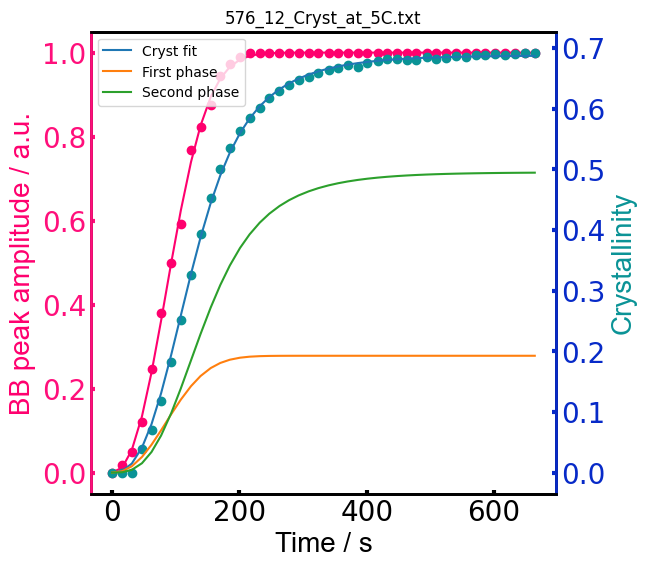

In [14]:
def ResultModel_5(t, A1, A2, K2, n2):
    K1 = 2.00612812e-05
    n1 = 2.3057208
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
#print(file_list)
df = pd.read_csv(path + '/' + file_list[8], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)
    
ax_2.spines['left'].set_color(color_BB)
ax.tick_params(axis='y', colors=color_BB)
ax_2.spines['right'].set_color(color_cr)
ax_2.tick_params(axis='y', colors=color_cr)

x = df['T'][:-60]
q = df['q'][:-60]
cr = df['cr'][:-60]

ax.scatter(x, 1-q, color='#ff006e')
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.plot(x, Avrami(x, *popt), color='#ff006e', label=f'BB fit')
# lst_K1.append(popt[1])
# lst_n1.append(popt[2])
print(popt)
# # , bounds=([0.15,0,0,0.5], [1, 0.4, 1e-1, 4])
p0 = [0.192544, 0.5, 0.028581, 0.86358]
popt, pcov = curve_fit(ResultModel_5, np.array(x), cr, p0=p0, bounds=([0.0,0,0,0.5], [0.5, 0.5, 1e-1, 3]))
print(*list(map(round, popt, [6]*len(popt))))
A1, A2, K2, n2 = popt
# lst_A1.append(A1)
# lst_A2.append(A2)
# lst_K2.append(K2)
# lst_n2.append(n2)
ax_2.plot(x, ResultModel_5(np.array(x), *popt), label=f'Cryst fit')
ax_2.plot(x, Avrami(x, A1, 2.00612812e-05, 2.3057208), label=f'First phase')
ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 2.00612812e-05, 2.3057208, K2, n2), label=f'Second phase')
plt.legend()
plt.title(file_list[8])
ax_2.scatter(x, cr, color='#0a9396')
plt.plot()

[1.00320279e+00 1.24134301e-07 3.00000000e+00]


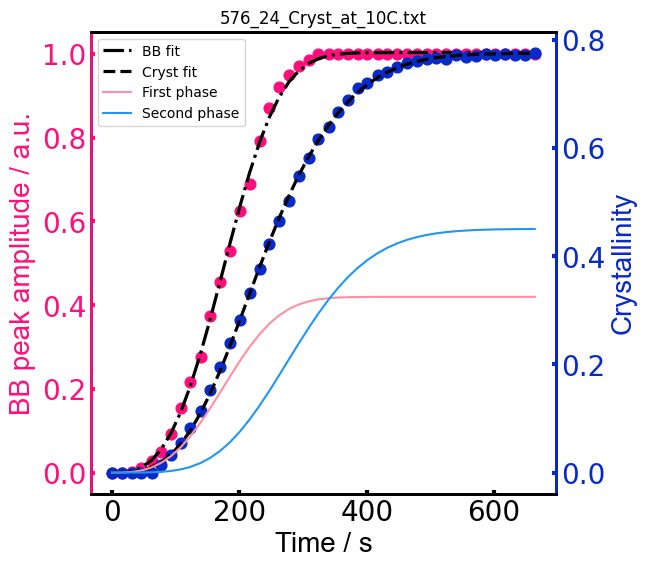

In [15]:
def ResultModel_6(t, A1, A2, K2, n2):
    K1 = 1.24652640e-07
    n1 = 3.0
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
#print(file_list)
df = pd.read_csv(path + '/' + file_list[9], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color=color_BB, fontdict=font)
ax_2.set_ylabel('Crystallinity', color=color_cr, fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)
ax_2.spines['left'].set_color(color_BB)
ax.tick_params(axis='y', colors=color_BB)
ax_2.spines['right'].set_color(color_cr)
ax_2.tick_params(axis='y', colors=color_cr)

x = df['T'][:-60]
q = df['q'][:-60]
cr = df['cr'][:-60]

ax.scatter(x, 1-q, color=color_BB, s=60)
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
line_bb = ax.plot(x, Avrami(x, *popt),linestyle='dashdot', linewidth=2.3,color='black',label=f'BB fit')
# lst_K1.append(popt[1])
# lst_n1.append(popt[2])
print(popt)
# # , bounds=([0.15,0,0,0.5], [1, 0.4, 1e-1, 1.7])
p0 = [0.324747, 0.454977, 0.000265, 1.7]
# popt, pcov = curve_fit(ResultModel_6, np.array(x), cr, p0=p0, bounds=([0.15,0,0,0.5], [1, 0.5, 1e-1, 1.7]))
# print(*list(map(round, popt, [6]*len(popt))))
A1, A2, K2, n2 = p0
# lst_A1.append(A1)
# lst_A2.append(A2)
# lst_K2.append(K2)
# lst_n2.append(n2)
line_cr = ax_2.plot(x, ResultModel_6(np.array(x), *p0),linestyle='dashed', linewidth=2.3,color='black',label=f'Cryst fit')
line_first_phase = ax_2.plot(x, Avrami(x, A1, 1.24652640e-07, 3.0), label=f'First phase', color='#ff8fa3')
line_second_phase = ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 1.24652640e-07, 3.0, K2, n2),color='#2196f3', label=f'Second phase')

lines = line_bb + line_cr + line_first_phase + line_second_phase
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left')

plt.title(file_list[9])
ax_2.scatter(x, cr, color=color_cr, s=60)
plt.show()

['292_12_Cryst_at_10C.txt' '292_12_Cryst_at_15C.txt'
 '292_12_Cryst_at_17_5C.txt' '292_24_Cryst_at_20C.txt'
 '292_6_Cryst_at_10C.txt' '292_6_Cryst_at_5C.txt'
 '576_12_Cryst_at_10C.txt' '576_12_Cryst_at_15C.txt'
 '576_12_Cryst_at_5C.txt' '576_24_Cryst_at_10C.txt'
 '576_24_Cryst_at_15C_second_sample.txt' '576_24_Cryst_at_20C.txt'
 '576_24_Cryst_at_5C.txt' '576_6_Cryst_at_0C.txt' '576_6_Cryst_at_10C.txt'
 '576_6_Cryst_at_15C.txt' '576_6_Cryst_at_5C.txt'
 '888_24_Cryst_at_15C.txt' '292_24_Cryst_at_10C.txt']
[1.00310397e+00 1.06291771e-06 3.00000000e+00]
0.34 0.429508 0.000747 1.705943


[]

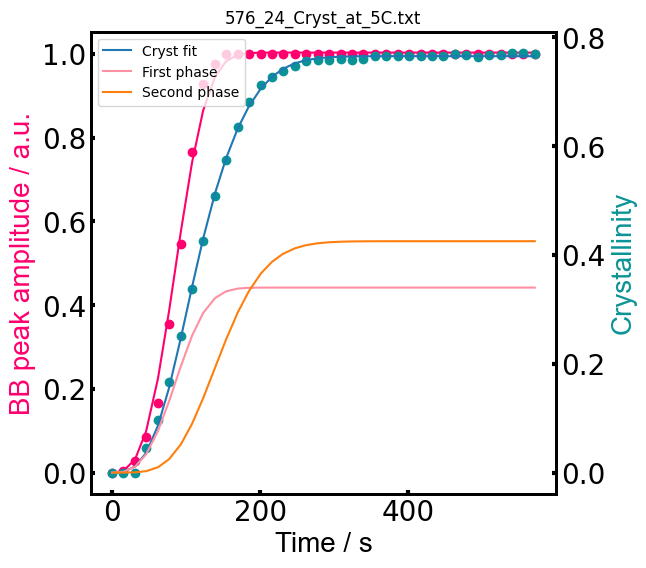

In [16]:
def ResultModel_7(t, A1, A2, K2, n2):
    K1 = 1.06630272e-06
    n1 = 3.0
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
print(file_list)
df = pd.read_csv(path + '/' + file_list[12], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)


x = df['T'][:-50]
q = df['q'][:-50]
cr = df['cr'][:-50]

ax.scatter(x, 1-q, color='#ff006e')
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.plot(x, Avrami(x, *popt), color='#ff006e', label=f'BB fit')
lst_K1.append(popt[1])
lst_n1.append(popt[2])
print(popt)
# # , bounds=([0.15,0,0,0.5], [1, 0.4, 1e-1, 4])
p0 = [0.302533, 0.4, 0.00117765, 1.483291]
popt, pcov = curve_fit(ResultModel_7, np.array(x), cr, p0=p0, bounds=([0.15,0,0,0.5], [0.34, 0.6, 1e-1, 4]))
print(*list(map(round, popt, [6]*len(popt))))
A1, A2, K2, n2 = popt
lst_A1.append(A1)
lst_A2.append(A2)
lst_K2.append(K2)
lst_n2.append(n2)
ax_2.plot(x, ResultModel_7(np.array(x), *popt), label=f'Cryst fit')
ax_2.plot(x, Avrami(x, A1, 1.06630272e-06, 3.), label=f'First phase', color='#ff8fa3')
ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 1.06630272e-06, 3., K2, n2), label=f'Second phase')
plt.legend()
plt.title(file_list[12])
ax_2.scatter(x, cr, color='#0a9396')
plt.plot()

In [ ]:
Samples = ['292_6_10', '292_24_10', '576_12_10', '576_12_15', '576_12_5', '576_24_10', '576_24_5']
df_results = pd.DataFrame({'Sample':Samples, 'A1':lst_A1, 'K1':lst_K1, 'n1':lst_n1, 'A2':lst_A2, 'K2':lst_K2, 'n2':lst_n2})
print(df_results)

#df_results.to_excel(r'D:\Kinetics/results_double_avrami.xlsx')\

[9.94991474e-01 1.49914693e-06 2.47685933e+00]
0.1 0.451319 0.108677 0.61804


[]

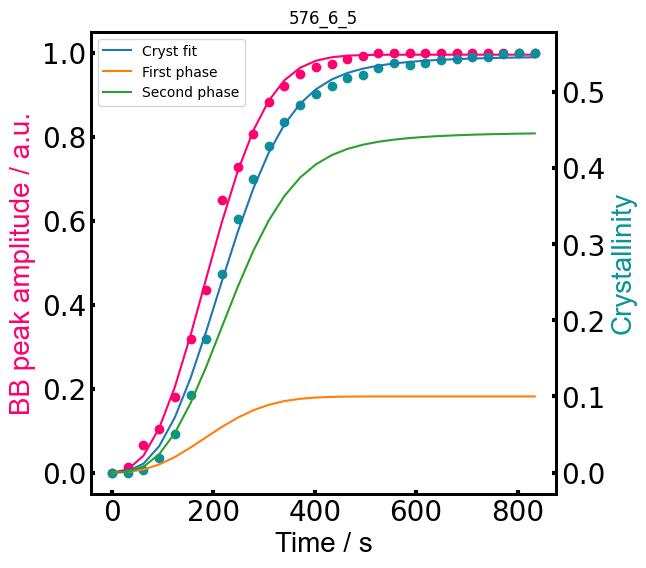

In [114]:
def ResultModel_8(t, A1, A2, K2, n2):
    K1 = 1.49914693e-06
    n1 = 2.4768593
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)


path = r'D:\general/results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_5C.csv'
df = pd.read_csv(path, sep='\t')

x = df['Time'][35:91:2].copy()
x -= x[35]
q_576_6_5 = np.array([1.0, 0.98573, 0.93441, 0.89669, 0.82015, 0.68095, 0.56524, 0.35011, 0.27195, 0.19456, 0.11696, 0.0787, 0.05112, 0.03408, 0.02646, 0.01574, 0.007784, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.0, 0])
cr = df['Crystalinity'][35:91:2].copy()
cr/=0.94
fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)

ax.scatter(x, 1-q_576_6_5, color='#ff006e')
p0 = [1, 1e-6, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q_576_6_5, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.plot(x, Avrami(x, *popt), color='#ff006e', label=f'BB fit')    
print(popt)

p0 = [0.2, 0.3, 0.017765, 1.083291]
popt, pcov = curve_fit(ResultModel_8, np.array(x), cr, p0=p0, bounds=([0.1,0.1,0,0.5], [0.6, 0.6, 9e-1, 4]))
print(*list(map(round, popt, [6]*len(popt))))
A1, A2, K2, n2 = popt
# lst_A1.append(A1)
# lst_A2.append(A2)
# lst_K2.append(K2)
# lst_n2.append(n2)
ax_2.plot(x, ResultModel_8(np.array(x), *popt), label=f'Cryst fit')
ax_2.plot(x, Avrami(x, A1, 1.49914693e-06, 2.4768593), label=f'First phase')
ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 1.49914693e-06, 2.4768593, K2, n2), label=f'Second phase')
plt.legend()
plt.title(f'576_6_5')
ax_2.scatter(x, cr, color='#0a9396')
plt.plot()


[1.00382397e+00 1.83038160e-07 2.49298500e+00]


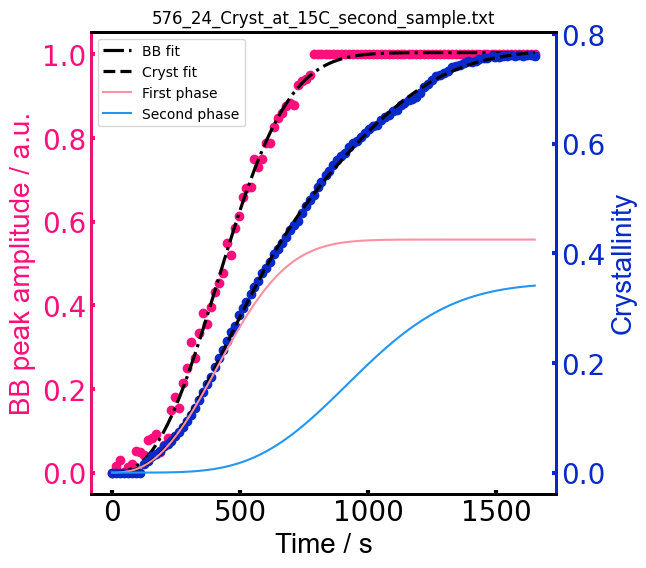

In [18]:
def ResultModel_9(t, A1, A2, K2, n2):
    K1 = 1.60648050e-07
    n1 = 2.51489
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

color_BB = '#ff0f7b'
color_cr = '#072ac8'
path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
df = pd.read_csv(path + '/' + file_list[10], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color=color_BB, fontdict=font)
ax_2.set_ylabel('Crystallinity', color=color_cr, fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)
ax_2.spines['left'].set_color(color_BB)
ax.tick_params(axis='y', colors=color_BB)
ax_2.spines['right'].set_color(color_cr)
ax_2.tick_params(axis='y', colors=color_cr)

x = df['T'][:-30]
q = df['q'][:-30]
cr = df['cr'][:-30]

ax.scatter(x, 1-q, color=color_BB)
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
line_bb = ax.plot(x, Avrami(x, *popt), linestyle='dashdot', linewidth=2.3, color='black', label=f'BB fit')
lst_K1.append(popt[1])
lst_n1.append(popt[2])
print(popt)

p0 = [0.42493676, 0.3493897, 2.3e-07, 2.40312261]
#popt, pcov = curve_fit(ResultModel_9, np.array(x), cr, p0=p0, bounds=([0.1,0.1,0,0.5], [1.0, 1.0, 9e-1, 4]))
#print(*list(map(round, popt, [8]*len(popt))))
A1, A2, K2, n2 = p0
# lst_A1.append(A1)
# lst_A2.append(A2)
# lst_K2.append(K2)
# lst_n2.append(n2)
line_cr = ax_2.plot(x, ResultModel_9(np.array(x), *p0), linestyle='dashed', linewidth=2.3, color='black', label=f'Cryst fit')
line_first_phase = ax_2.plot(x, Avrami(x, A1, 1.60648050e-07, 2.51489), label=f'First phase', color='#ff8fa3')
line_second_phase = ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 1.60648050e-07, 2.51489, K2, n2), color='#2196f3', label=f'Second phase')

lines = line_bb + line_cr + line_first_phase + line_second_phase
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left')

plt.title(file_list[10])
ax_2.scatter(x, cr, color=color_cr)
plt.show()

[1.00258703e+00 4.42177865e-06 2.22544405e+00]
0.19700658 0.45408571 0.00062262 1.58737052


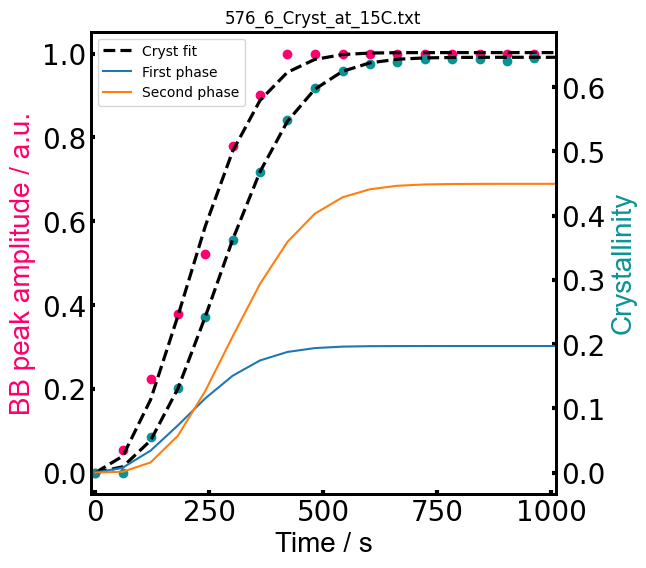

In [104]:
def ResultModel_10(t, A1, A2, K2, n2):
    K1 = 4.42177865e-06
    n1 = 2.22544
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
df = pd.read_csv(path + '/' + file_list[-4], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)


x = df['T'][:-10]
q = df['q'][:-10]
cr = df['cr'][:-10]

ax.scatter(x, 1-q, color='#ff006e')
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.plot(x, Avrami(x, *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'BB fit')
# lst_K1.append(popt[1])
# lst_n1.append(popt[2])
print(popt)

p0 = [0.44, 0.2, 2.3e-4, 1.40291]
popt, pcov = curve_fit(ResultModel_10, np.array(x), cr, p0=p0, bounds=([0.1,0.1,0,0.5], [0.6, 0.6, 9e-1, 3]))
print(*list(map(round, popt, [8]*len(popt))))
A1, A2, K2, n2 = popt
# lst_A1.append(A1)
# lst_A2.append(A2)
# lst_K2.append(K2)
# lst_n2.append(n2)
ax_2.plot(x, ResultModel_10(np.array(x), *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'Cryst fit')
ax_2.plot(x, Avrami(x, A1, 4.42177865e-06, 2.22544), label=f'First phase')
ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 4.42177865e-06, 2.22544, K2, n2), label=f'Second phase')
plt.legend()
plt.xlim(-10, 1010)
plt.title(file_list[-4])
ax_2.scatter(x, cr, color='#0a9396')
plt.show()

['292_12_Cryst_at_10C.txt' '292_12_Cryst_at_15C.txt'
 '292_12_Cryst_at_17_5C.txt' '292_24_Cryst_at_20C.txt'
 '292_6_Cryst_at_10C.txt' '292_6_Cryst_at_5C.txt'
 '576_12_Cryst_at_10C.txt' '576_12_Cryst_at_15C.txt'
 '576_12_Cryst_at_5C.txt' '576_24_Cryst_at_10C.txt'
 '576_24_Cryst_at_15C_second_sample.txt' '576_24_Cryst_at_20C.txt'
 '576_24_Cryst_at_5C.txt' '576_6_Cryst_at_0C.txt' '576_6_Cryst_at_10C.txt'
 '576_6_Cryst_at_15C.txt' '576_6_Cryst_at_5C.txt'
 '888_24_Cryst_at_15C.txt' '292_24_Cryst_at_10C.txt']
[1.00008043e+00 8.76939072e-07 2.83148041e+00]
0.30581057 0.27542348 0.01 0.98339692


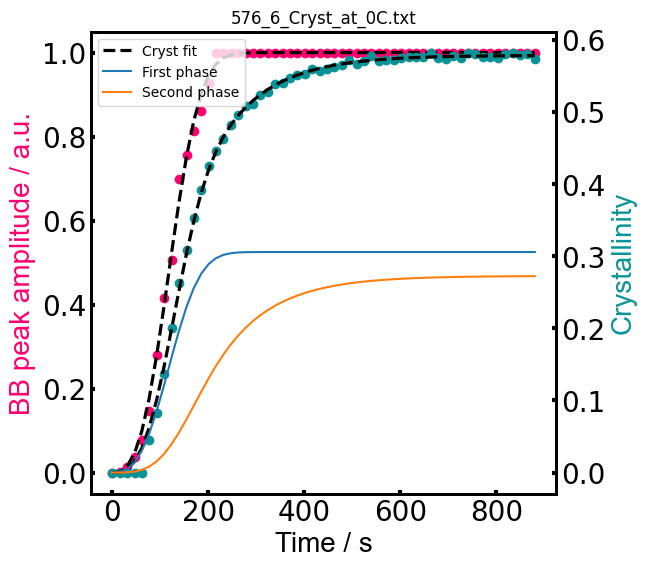

In [20]:
def ResultModel_11(t, A1, A2, K2, n2):
    K1 = 8.76939072e-07
    n1 = 2.831
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
print(file_list)
df = pd.read_csv(path + '/' + file_list[-6], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)


x = df['T'][:-30]
q = df['q'][:-30]
cr = df['cr'][:-30]

ax.scatter(x, 1-q, color='#ff006e')
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.plot(x, Avrami(x, *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'BB fit')
# # lst_K1.append(popt[1])
# # lst_n1.append(popt[2])
print(popt)

p0 = [0.43, 0.15, 1.3e-3, 1.30291]
popt, pcov = curve_fit(ResultModel_11, np.array(x), cr, p0=p0, bounds=([0.1,0.1,0,0.3], [0.6, 0.6, 1e-2, 3]))
print(*list(map(round, popt, [8]*len(popt))))
A1, A2, K2, n2 = popt
# lst_A1.append(A1)
# lst_A2.append(A2)
# lst_K2.append(K2)
# lst_n2.append(n2)
ax_2.plot(x, ResultModel_11(np.array(x), *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'Cryst fit')
ax_2.plot(x, Avrami(x, A1, 8.76939072e-07, 2.831), label=f'First phase')
ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 8.76939072e-07, 2.831, K2, n2), label=f'Second phase')
plt.legend()
plt.title(file_list[-6])
ax_2.scatter(x, cr, color='#0a9396')
plt.show()

['292_12_Cryst_at_10C.txt' '292_12_Cryst_at_15C.txt'
 '292_12_Cryst_at_17_5C.txt' '292_24_Cryst_at_20C.txt'
 '292_6_Cryst_at_10C.txt' '292_6_Cryst_at_5C.txt'
 '576_12_Cryst_at_10C.txt' '576_12_Cryst_at_15C.txt'
 '576_12_Cryst_at_5C.txt' '576_24_Cryst_at_10C.txt'
 '576_24_Cryst_at_15C_second_sample.txt' '576_24_Cryst_at_20C.txt'
 '576_24_Cryst_at_5C.txt' '576_6_Cryst_at_0C.txt' '576_6_Cryst_at_10C.txt'
 '576_6_Cryst_at_15C.txt' '576_6_Cryst_at_5C.txt'
 '888_24_Cryst_at_15C.txt' '292_24_Cryst_at_10C.txt']
[1.00184938e+00 1.41420755e-05 2.20434254e+00]


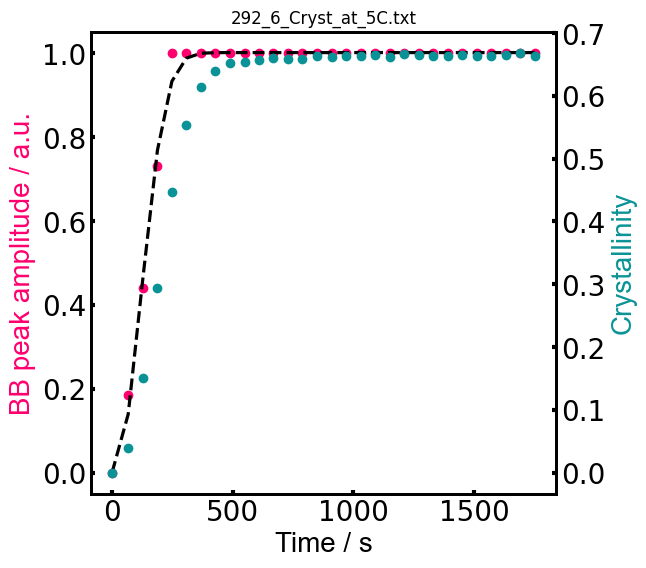

In [107]:
def ResultModel_11(t, A1, A2, K2, n2):
    K1 = 8.76939072e-07
    n1 = 2.831
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
print(file_list)
df = pd.read_csv(path + '/' + file_list[5], sep ="\t", skiprows=1, names=['T', 'q', 'cr'])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)


x = df['T'][:]
q = df['q'][:]
cr = df['cr'][:]

ax.scatter(x, 1-q, color='#ff006e')
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(x), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.plot(x, Avrami(x, *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'BB fit')
# # lst_K1.append(popt[1])
# # lst_n1.append(popt[2])
print(popt)

# p0 = [0.43, 0.15, 1.3e-3, 1.30291]
# popt, pcov = curve_fit(ResultModel_11, np.array(x), cr, p0=p0, bounds=([0.1,0.1,0,0.3], [0.6, 0.6, 1e-2, 3]))
# print(*list(map(round, popt, [8]*len(popt))))
# A1, A2, K2, n2 = popt
# # lst_A1.append(A1)
# # lst_A2.append(A2)
# # lst_K2.append(K2)
# # lst_n2.append(n2)
# ax_2.plot(x, ResultModel_11(np.array(x), *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'Cryst fit')
# ax_2.plot(x, Avrami(x, A1, 8.76939072e-07, 2.831), label=f'First phase')
# ax_2.plot(x, Avraami_2_linspace(np.array(x), A2, 8.76939072e-07, 2.831, K2, n2), label=f'Second phase')
# plt.legend()
plt.title(file_list[5])
ax_2.scatter(x, cr, color='#0a9396')
plt.show()

[1.00767602e+00 4.17664084e-08 2.66176173e+00]


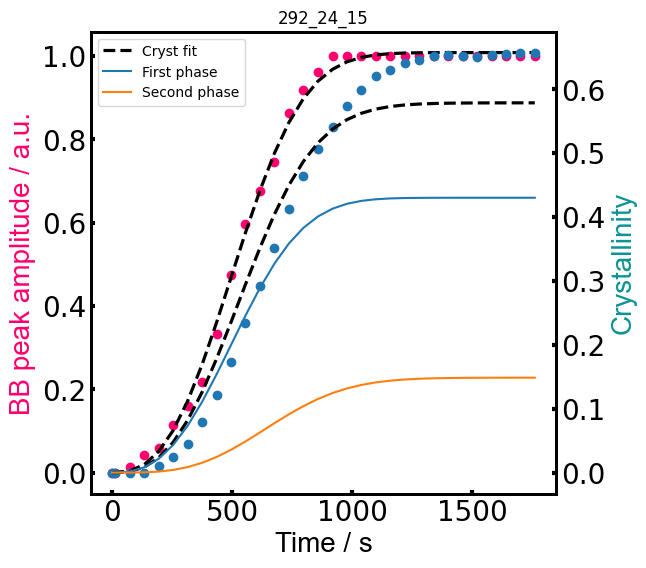

In [202]:
def ResultModel_12(t, A1, A2, K2, n2):
    K1 = 4.17664084e-08
    n1 = 2.66176
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:\general/results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_15C.csv'
df = pd.read_csv(path, sep='\t')
time = df['Time'][30:61].copy()
time -= time[30]
#q = df['q1_Ampl'][30:61]
cr = df['Crystalinity'][30:61].copy()
cr/=(1-0.22)
#q/=q[30]
q = np.array([1.0, 1.0, 0.98558, 0.95822, 0.94105, 0.88536, 0.84085, 0.78165, 0.66836, 0.52705, 0.40438, 0.32376, 0.25418, 0.1376, 0.08234, 0.038374587, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)

    
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(time), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.plot(time, Avrami(time, *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'BB fit')
print(popt)

p0 = [0.43, 0.15, 1.3e-3, 1.30291]
# popt, pcov = curve_fit(ResultModel_12, np.array(time), cr, p0=p0, bounds=([0,0,0,0.3], [0.8, 0.8, 1e-2, 3]))
# print(*list(map(round, popt, [8]*len(popt))))
A1, A2, K2, n2 = p0
# lst_A1.append(A1)
# lst_A2.append(A2)
# lst_K2.append(K2)
# lst_n2.append(n2)
ax_2.plot(np.array(time), ResultModel_12(np.array(time), *p0), linestyle='dashed', linewidth=2.3, color='black', label=f'Cryst fit')
ax_2.plot(np.array(time), Avrami(np.array(time), A1, 4.17664084e-08, 2.66176), label=f'First phase')
ax_2.plot(np.array(time), Avraami_2_linspace(np.array(time), A2, 4.17664084e-08, 2.66176, K2, n2), label=f'Second phase')
plt.legend()

ax.scatter(time, 1-q, color='#ff006e')
plt.title('292_24_15')
ax_2.scatter(time, cr)
plt.show()

[1.01360357e+00 8.95006454e-07 2.18107205e+00]
0.0 0.66040805 2.9e-07 2.93381953


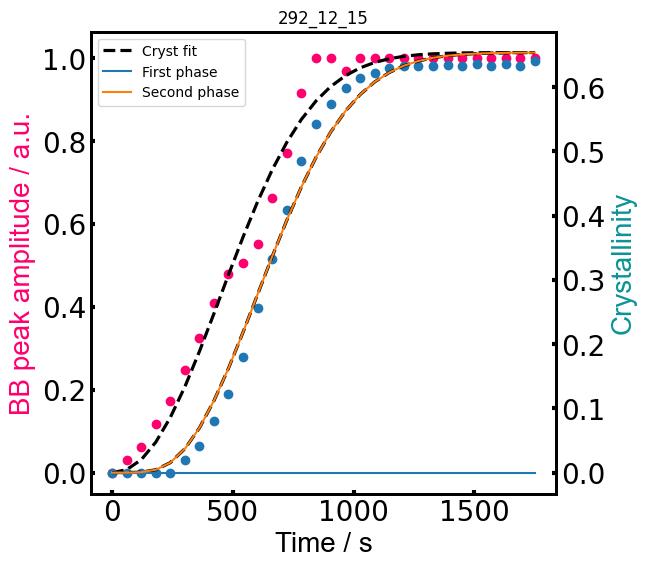

In [210]:
def ResultModel_13(t, A1, A2, K2, n2):
    K1 = 8.95006454e-07
    n1 = 2.1810
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

path = r'D:\general/results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_15C.csv'
df = pd.read_csv(path, sep='\t')
time = df['Time'][31:61].copy()
time -= time[31]
q = df['q1_Ampl'][31:61]
cr = df['Crystalinity'][31:61].copy()
cr/=(1-0.12)
q/=q[31]
#q = np.array([1.0, 1.0, 0.98558, 0.95822, 0.94105, 0.88536, 0.84085, 0.78165, 0.66836, 0.52705, 0.40438, 0.32376, 0.25418, 0.1376, 0.08234, 0.038374587, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

fig, ax = plt.subplots(figsize=(6,6))
ax_2 = ax.twinx()
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('BB peak amplitude / a.u.', color='#ff006e', fontdict=font)
ax_2.set_ylabel('Crystallinity', color='#0a9396', fontdict=font)

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax_2.xaxis.set_major_formatter(ScalarFormatter())
ax_2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
for axis in ['top','bottom','left','right']:
    ax_2.spines[axis].set_linewidth(2)

    
p0 = [1, 1e-7, 2.5]
popt, pcov = curve_fit(Avrami, np.array(time), 1 - q, p0=p0, bounds=([0.9, 0, 1], [1.1, 1e-1, 3]))
ax.plot(time, Avrami(time, *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'BB fit')
print(popt)

p0 = [0.43, 0.15, 1.3e-3, 1.30291]
popt, pcov = curve_fit(ResultModel_13, np.array(time), cr, p0=p0, bounds=([0,0,0,0.3], [0.8, 0.8, 1e-2, 3]))
print(*list(map(round, popt, [8]*len(popt))))
A1, A2, K2, n2 = popt
# lst_A1.append(A1)
# lst_A2.append(A2)
# lst_K2.append(K2)
# lst_n2.append(n2)
ax_2.plot(np.array(time), ResultModel_13(np.array(time), *popt), linestyle='dashed', linewidth=2.3, color='black', label=f'Cryst fit')
ax_2.plot(np.array(time), Avrami(np.array(time), A1, 8.95006454e-07, 2.18107), label=f'First phase')
ax_2.plot(np.array(time), Avraami_2_linspace(np.array(time), A2, 8.95006454e-07, 2.18107, K2, n2), label=f'Second phase')
plt.legend()

ax.scatter(time, 1-q, color='#ff006e')
plt.title('292_12_15')
ax_2.scatter(time, cr)
plt.show()

1000


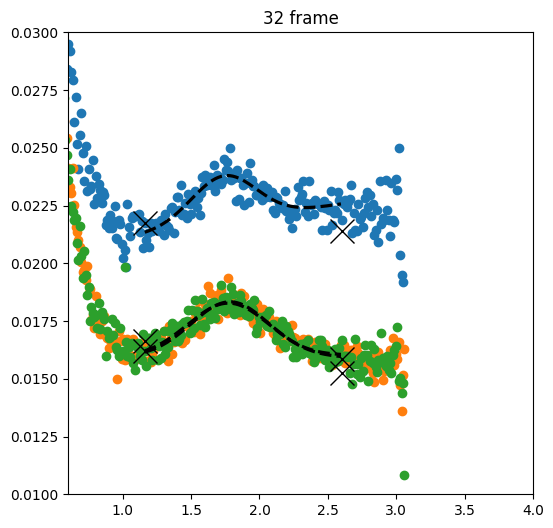

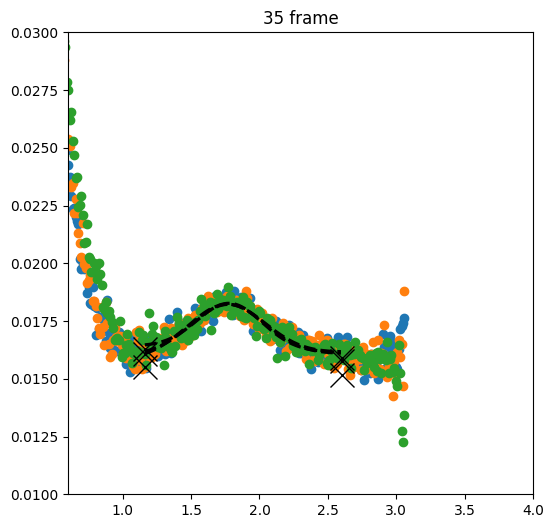

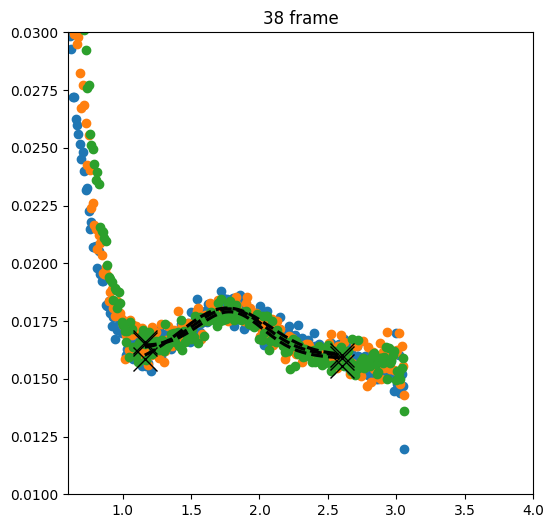

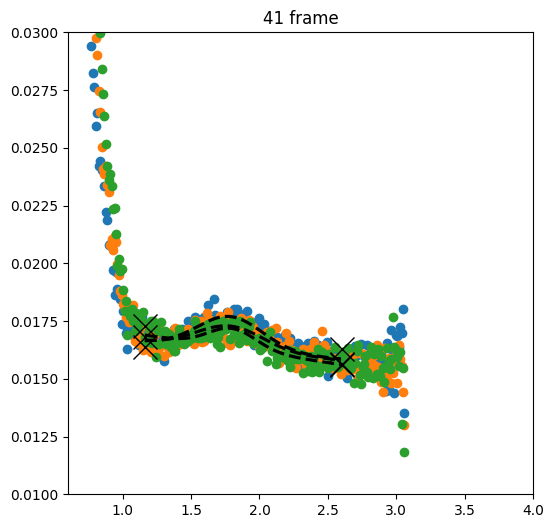

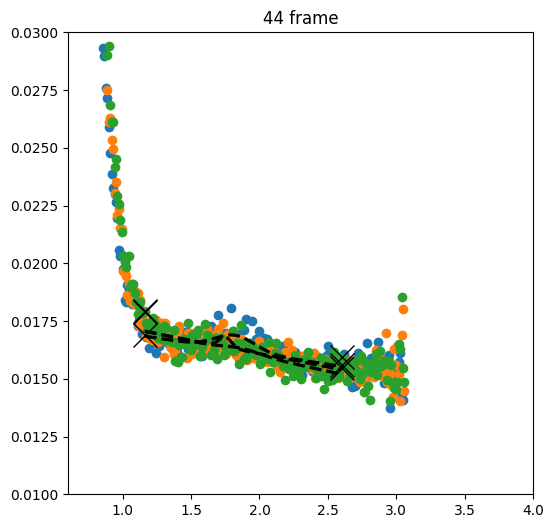

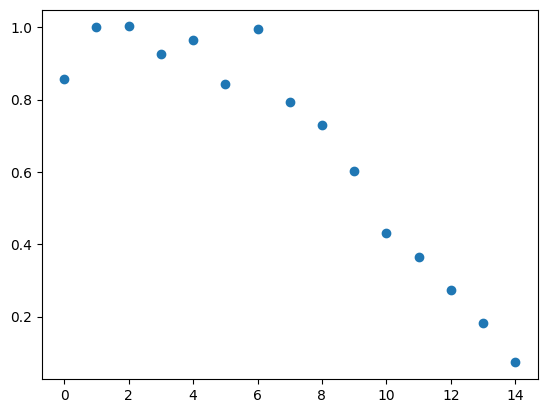

In [163]:
def Gauss_and_linear(x, A, center, sigma, k, b):
    return A*np.exp(-(x-center)**2/sigma) + k*x + b

path = r'D:\BM26\PEG_PNIPAM_292_24_Cryst_at_15C'
Exp = BM26_experiment(path)
Trms = Exp.get_Tr_profile()
lst_A = []
q_start, I_start = Exp.get_1d_SAXS(29)
print(len(q_start))
I_start/=Trms[29]
for n in range(30, 45):
    if n%3==0:
        plt.figure(figsize=(6, 6))
        plt.xlim(0.6, 4)
        plt.ylim(1e-2, 3e-2)
    q, I = Exp.get_1d_SAXS(n)
    I/= Trms[n]
    x = q[330:740:3]
    y = I[330:740:3]
    if n==30:
        p0 = [0.5e-2, 1.8, 0.5, 0, 2e-2]
    else: p0=popt
    popt, pcov = curve_fit(Gauss_and_linear, x, y, p0 = p0)
    plt.plot(x, Gauss_and_linear(x, *popt), linestyle='dashed', color='black', linewidth=2.3)
    lst_A.append(popt[0])
    plt.scatter(q[::3], I[::3])
    plt.plot(q[330], I[330], 'x', markersize=17, color='black')
    plt.plot(q[740], I[740], 'x', markersize=17, color='black')
    plt.title(f'{n} frame')
res = np.array(lst_A)
res/=res[1]
plt.figure()
plt.scatter([i for i in range(len(res))], res)
plt.show()

In [ ]:
def Gauss_and_linear(x, A, center, sigma, k, b):
    return A*np.exp(-(x-center)**2/sigma) + k*x + b

path = r'\\Synology\Data\2024\SC-5624\PEG_PNIPAM_576_6_Cryst_5C'
Exp = BM26_experiment(path)

# SAXS_plot(6, 6)
# plt.xlim(0.8, 4)
# plt.ylim(1.3e-2, 4e-2)
lst_A = []
for n in range(35, 91, 2):
    if n%5==0:
        SAXS_plot(6, 6)
        plt.xlim(0.8, 4)
        plt.ylim(1.3e-2, 4e-2)
    q1, I1 = Exp.get_1d_SAXS(n)
    q2, I2 = Exp.get_1d_SAXS(n+1)
    q = q1
    I = I1/2+I2/2
    x = q[-1413:-500]
    y = I[-1413:-500]
    plt.plot(q[-500], I[-500], 'x', markersize=15.0, color='black')
    plt.plot(q[-1413], I[-1413], 'x', markersize=15.0, color='black')
    if n==35:
        p0 = [0.5e-2, 1.8, 1, 0, 2e-2]
    else:
        p0 = popt
        
    popt, pcov = curve_fit(Gauss_and_linear, x, y, p0=p0, bounds=([0,1.5, 1e-2, -1, -1], [1e-1, 2, 3, 1, 1]))
    plt.plot(x, Gauss_and_linear(x, *popt), linestyle='dashed', color='black', linewidth=2.3)
    plt.scatter(q, I, s=3)
    lst_A.append(popt[0])
    plt.title(f'{n} frame')
    if abs(popt[0])<1e-5:
        break
        print(n)

plt.show()

In [77]:
path = r'D:/Kinetics'
file_list = np.array(os.listdir(path))
df1 = pd.read_csv(path + '/' + file_list[10], sep ="\t", skiprows=1, names=['T', 'q', 'cr']) # 576_24_15
cr24_15 = df1['cr'][:-30]
df2 = pd.read_csv(path + '/' + file_list[9], sep ="\t", skiprows=1, names=['T', 'q', 'cr']) # 576_24_10
df3 = pd.read_csv(path + '/' + file_list[7], sep ="\t", skiprows=1, names=['T', 'q', 'cr']) # 576_12_15
cr24_10 = df2['cr'][:-60]
cr12_15 = df3['cr'][1:]

Found 192 EDF files in SAXS
33


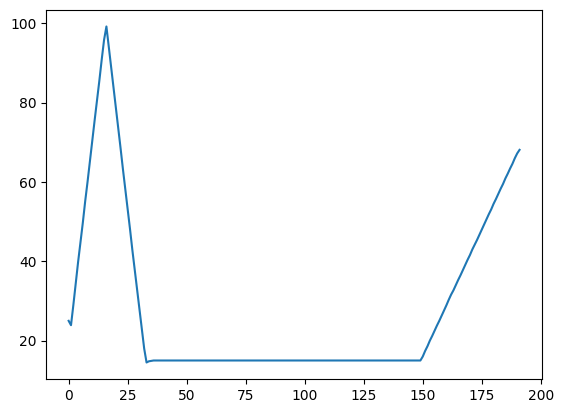

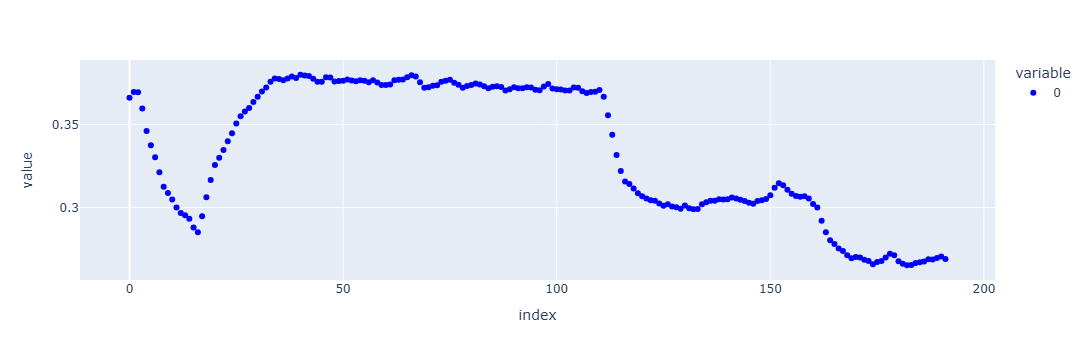

40
50
60
70
80
90
100
110
120
130
140
150
108
108


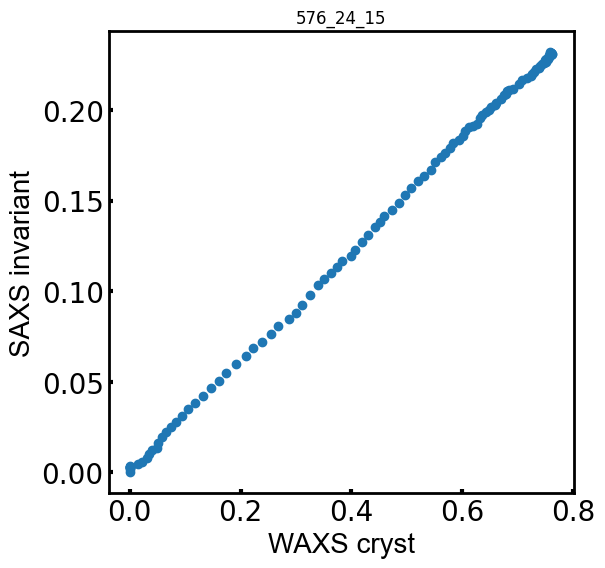

In [222]:
path = r'D:\BM26\PEG_PNIPAM_576_24_Cryst_15C_second_sample'
Exp = BM26_experiment(path)
T = Exp.get_T_profile()
print(np.argmin(T)) # 33
plt.plot(T)
plt.show()
Trms = Exp.get_Tr_profile()
fig = px.scatter(Trms, color_discrete_sequence=['blue'])
fig.show()

Time = Exp.get_Time_profile()
Time -= Time[33]
Inv = []
q_start, I_start = Exp.get_1d_SAXS(np.argmin(T))
I_start /= Trms[np.argmin(T)]
for n in range(33, 151):
    if n%10==0:
        print(n)
    # SAXS_plot(6, 6)
    # plt.xlim(0.03, 3)
    q, I = Exp.get_1d_SAXS(n)
    I/= Trms[n]
    I -= I_start
    I*=q**2
    res = integrate.simpson(I[28:580], q[28:580])
    Inv.append(res)
    # plt.scatter(q, I)
    # plt.plot(q[28], I[28], 'x', color='black', markersize=12)
    # plt.plot(q[580], I[580], 'x', color='black', markersize=12)

fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('SAXS Invariant / a.u.', fontdict=font)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
#ax.set_xticks([0, 500, 1000, 1500])
print(len(Inv[:-10]))
print(len(cr24_15))
ax.scatter(cr24_15, Inv[:-10])
#ax.set_xlim(-10, 1710)
plt.title('576_24_15')
ax.set_xlabel('WAXS cryst')
ax.set_ylabel('SAXS invariant')
plt.show()

Found 94 EDF files in SAXS
53


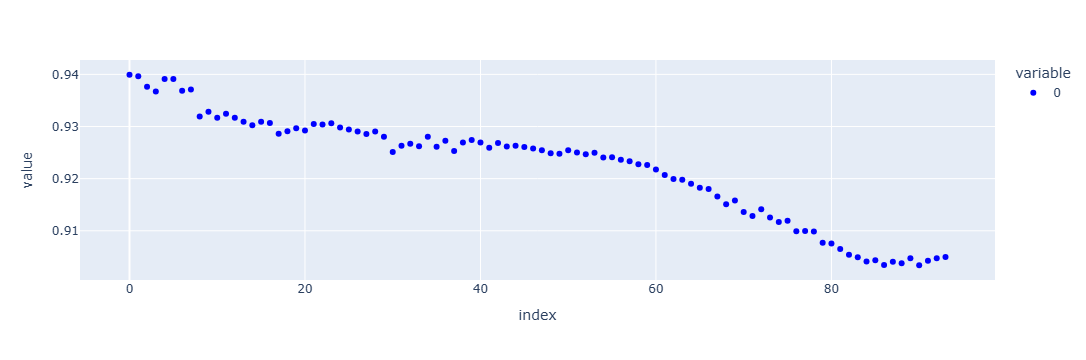

16
16


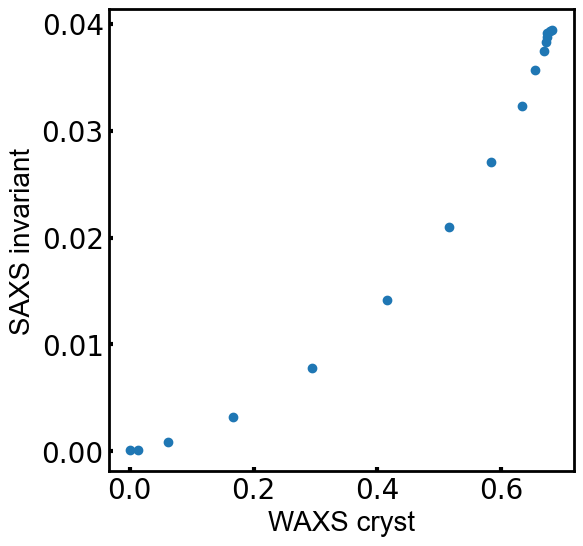

In [63]:
path = r'D:\BM26\PEG_PNIPAM_576_12_Cryst_at_15C'
Exp = BM26_experiment(path)
T = Exp.get_T_profile()
print(np.argmin(T))
# plt.plot(T)
# plt.show()
Time = Exp.get_Time_profile()
Time -= Time[np.argmin(T)]

Trms = Exp.get_Tr_profile()
fig = px.scatter(Trms, color_discrete_sequence=['blue'])
fig.show()

Inv = []
q_start, I_start = Exp.get_1d_SAXS(np.argmin(T))
I_start /= Trms[33]
for n in range(53, 87):
    # SAXS_plot(6, 6)
    # plt.xlim(0.03, 3)
    q, I = Exp.get_1d_SAXS(n)
    I/= Trms[n]
    I -= I_start
    I*=q**2
    res = integrate.simpson(I[17:281], q[17:281])
    Inv.append(res)
    # plt.scatter(q, I)
    # plt.plot(q[17], I[17], 'x', color='black', markersize=12)
    # plt.plot(q[280], I[280], 'x', color='black', markersize=12)
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('SAXS Invariant / a.u.', fontdict=font)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
#ax.set_xticks([0, 500, 1000, 1500])
print(len(Inv[1:17]))
print(len(cr12_15[1:]))
ax.scatter(cr12_15[1:17], Inv[1:17])
#ax.set_xlim(-10, 1710)
ax.set_xlabel('WAXS cryst')
ax.set_ylabel('SAXS invariant')
plt.show()

Found 156 EDF files in SAXS
33


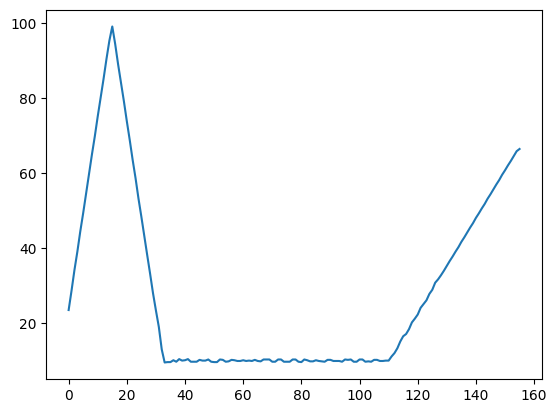

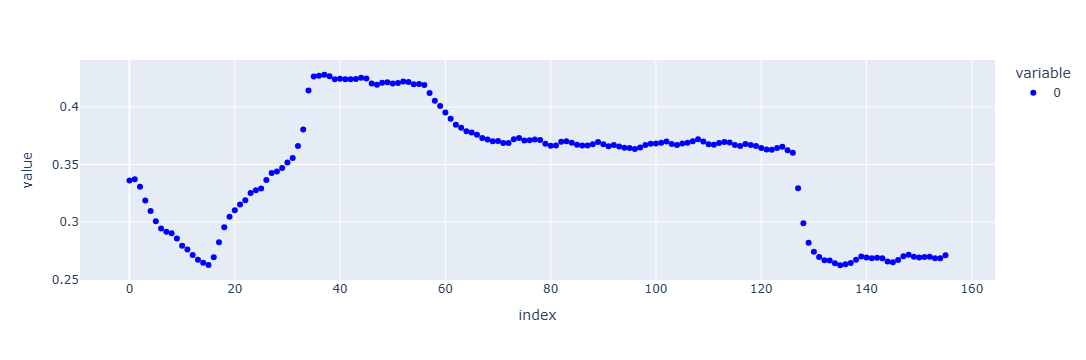

44
44


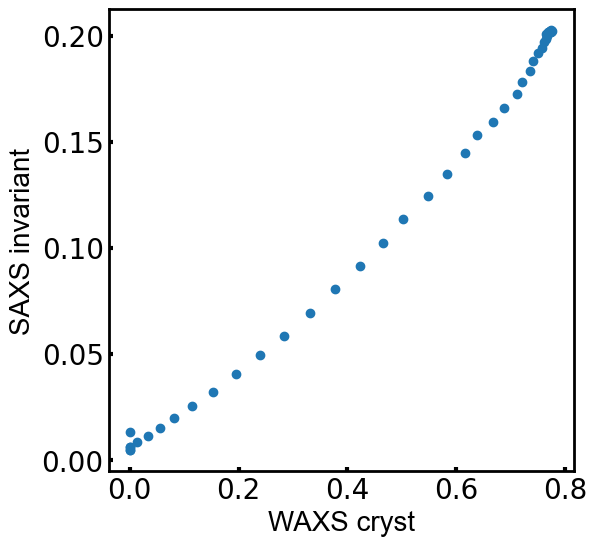

In [221]:
path = r'D:\BM26\PEG_PNIPAM_576_24_Cryst_10C'
Exp = BM26_experiment(path)
T = Exp.get_T_profile()
print(np.argmin(T)) # 33
plt.plot(T)
plt.show()

Time = Exp.get_Time_profile()
Time -= Time[33]

Trms = Exp.get_Tr_profile()
fig = px.scatter(Trms, color_discrete_sequence=['blue'])
fig.show()

Inv = []
q_start, I_start = Exp.get_1d_SAXS(np.argmin(T))
I_start /= Trms[np.argmin(T)]
for n in range(np.argmin(T), 110):
    
    q, I = Exp.get_1d_SAXS(n)
    I/=Trms[n]
    I -= I_start*0.9
    I*=q**2
    res = integrate.simpson(I[30:550], q[30:550])
    Inv.append(res)
    # if n%7==0:
    #     SAXS_plot(6, 6)
    #     plt.xlim(0.03, 3)
    #     plt.scatter(q, I)
    #     plt.plot(q[30], I[30], 'x', color='black', markersize=12)
    #     plt.plot(q[550], I[550], 'x', color='black', markersize=12)
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlabel('Time / s', fontdict=font)
ax.set_ylabel('SAXS Invariant / a.u.', fontdict=font)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
#ax.set_xticks([0, 500, 1000, 1500])
print(len(Inv[:-33]))
print(len(cr24_10))
ax.scatter(cr24_10, Inv[:-33])
#ax.set_xlim(-10, 1710)
ax.set_xlabel('WAXS cryst')
ax.set_ylabel('SAXS invariant')
plt.show()